In [56]:
import pickle
import pandas as pd
import re
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os


In [69]:
with open("/workspace/CCE_NLI/code/Abstractions/final_abstractions.pkl", 'rb') as f:
    abs_map = pickle.load(f)

In [70]:
len(abs_map)

144

In [255]:
abs_map[100]

['football',
 'frisbee',
 'baseball',
 'karaoke',
 'sport',
 'darts',
 'hopscotch',
 'chess',
 'soccer',
 'hockey',
 'basketball',
 'sporty',
 'badminton',
 'polo',
 'sporting',
 'jenga',
 'athletic',
 'softball',
 'athletics',
 'basketballs',
 'volleyball',
 'pong',
 'frisbees',
 'tennis',
 'golf',
 'sports']

In [242]:
def get_indiv_concepts(formula) -> set:
    concepts = set()
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.add(c[:end_idx])
    return concepts

def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw=[]
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        raw.extend(concepts)
    
    return unit_concepts, set(raw)

def build_binary_mask(neuron_mask, foundational_concept_list) -> torch.Tensor:
    num_neurons = len(neuron_mask)
    num_concepts = len(foundational_concept_list)

    # Step 1: Initialize tensor
    tensor = torch.zeros((num_neurons, num_concepts), dtype=torch.float32)

    # Step 2: Fill in ones
    for i, concepts in enumerate(neuron_mask.values()):
        for j, concept in enumerate(foundational_concept_list):
            if concept in concepts:
                tensor[i, j] = 1.0

    # Step 3: Compute row sums
    row_sums = tensor.sum(dim=1, keepdim=True)

    # Step 4: Normalize safely
    dist_tensor = torch.zeros_like(tensor)
    row_mask = (row_sums != 0).squeeze(1)  # True for rows with sum > 0
    dist_tensor[row_mask] = tensor[row_mask] #/ row_sums[row_mask]

    return dist_tensor



def get_neurons_for_cps(concepts, mapping):
    neurons = []
    for neuron, cps in mapping.items():
        for c in cps:
            if c in concepts:
                neurons.append(neuron)
                break
    return neurons

def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(lambda: defaultdict(set))
    s=set()
    for csv_file in csv_files:
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[csv_file.split("/")[-2]][csv_file.split("/")[-1]].update(get_indiv_concepts(formula))
            s.update(get_indiv_concepts(formula))
     
      
    return concept_dict, s


In [209]:


def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster
def find_abstractions(expls):
    if isinstance(expls, set):
        glob = expls
    else:
        glob = set([i for j in expls.values() for i in j ])
    abstracts=[]
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        if abstraction_cluster==143: 
            continue
        abstracts.append(abstraction_cluster)
    return Counter(abstracts), set(abstracts)


In [256]:
all_models_all_methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
validruns=defaultdict(lambda: defaultdict(int))
models=['LLAMA', 'BERT', 'BOWMAN']

methods=['CoFi','lottery_ticket']
for model in models:
    for method in methods:
        valid_runs=0
        for fname in range(5,8):
            try:
                cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')
                if not cluster_to_concepts:
                    break
                if fname==5:
                    dense = cluster_to_concepts['0.0%Pruned']
                    freq_dense, dense_abs=find_abstractions(dense)
                start=1
                for sparsity in cluster_to_concepts:
                    if sparsity == '0.0%Pruned': continue

                    sparse = cluster_to_concepts[sparsity]
                    frequency, sparse_abs = find_abstractions(sparse)
               
                    iou=len(sparse_abs&dense_abs)/len(dense_abs|sparse_abs)

                    all_models_all_methods_ious[model][method][start]+=iou
                    start+=1
                valid_runs+=1

            except Exception as e:
                print(e)

        validruns[model][method] = valid_runs
pi={0:0.0, 1:25.0, 2:43.75, 3:57.81, 4:68.36, 5:76.27, 6:82.03}
for mod, method_ in all_models_all_methods_ious.items():
    r=0
    for m, sparsity in method_.items():
        for s,iou in sparsity.items():
            all_models_all_methods_ious[mod][m][s]  /= validruns[mod][m]     
        r+=1
#rename x axis 
for mod, method_ in all_models_all_methods_ious.items():
    for m, sparsity in method_.items():
        print(list(sparsity.keys()))
        for s in list(sparsity.keys()):  # list() creates a copy so looping over old version
            all_models_all_methods_ious[mod][m][pi[s]] = sparsity.pop(s)


[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]


In [257]:
all_models_all_methods_ious

defaultdict(<function __main__.<lambda>()>,
            {'LLAMA': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'lottery_ticket': defaultdict(int,
                                      {25.0: 0.8347643097643098,
                                       43.75: 0.8519725557461406,
                                       57.81: 0.8056390382790257,
                                       68.36: 0.8162805662805663,
                                       76.27: 0.6538782318598833})}),
             'BERT': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'CoFi': defaultdict(int,
                                      {25.0: 0.8713338246131173,
                                       43.75: 0.8626584143825523,
                                       57.81: 0.8436176648517846,
                                       68.36: 0.8608590441621294,
                                       76.27: 0.8613568215892053}),
             

In [258]:
all_models_all_methods_ious=defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
validruns=defaultdict(lambda: defaultdict(int))
models=['LLAMA', 'BERT', 'BOWMAN']

methods=['CoFi','lottery_ticket']
for model in models:
    for method in methods:
        valid_runs=0
        dense_abstractions = []
        for fname in range(5,8):

            cluster_to_concepts, set_all_concepts = get_all_cps_for_pi(f'/workspace/CCE_NLI/{model}/exp/{method}/Run0.25_{fname}/Expls/')

            if not cluster_to_concepts:
                break
            

            if fname==5:
                dense = cluster_to_concepts['0.0%Pruned']
                
                for cluster in dense:
                    freq_dense, dense_abs=find_abstractions(dense[cluster])
                    
                    dense_abstractions.append(dense_abs)
            print(len(dense_abstractions))
            start=1
            for sparsity in cluster_to_concepts:
                sparse_abstractions = []
                if sparsity == '0.0%Pruned': continue

                sparse = cluster_to_concepts[sparsity]

                if len(sparse)!=3:continue
                for cluster in sparse:
                    frequency, sparse_abs = find_abstractions(sparse[cluster])
                    sparse_abstractions.append(sparse_abs)
                
                #get the iou for eahc index
                assert len(sparse_abstractions) == len(dense_abstractions), f"{len(sparse_abstractions)} != {len(dense_abstractions)}"
                iou= [len(s&d)/ len(s|d) for s,d in zip(sparse_abstractions, dense_abstractions)]

                #add the lists 
                if all_models_all_methods_ious[model][method][start] :
                    all_models_all_methods_ious[model][method][start] = [a + b for a, b in zip(all_models_all_methods_ious[model][method][start], iou)]
                else:
                    all_models_all_methods_ious[model][method][start]  = iou
                start+=1
            valid_runs+=1
            print("VALDI ", valid_runs)
           

        validruns[model][method] = valid_runs
print(validruns)
pi={0:0.0, 1:25.0, 2:43.75, 3:57.81, 4:68.36, 5:76.27, 6:82.03}
for mod, method_ in all_models_all_methods_ious.items():
    r=0
    for m, sparsity in method_.items():
        for s,iou in sparsity.items():
            print(all_models_all_methods_ious[mod][m][s])
            all_models_all_methods_ious[mod][m][s]  = [a/validruns[mod][m]   for a in  all_models_all_methods_ious[mod][m][s]]
            print(all_models_all_methods_ious[mod][m][s])
            
        r+=1
#rename x axis 
for mod, method_ in all_models_all_methods_ious.items():
    for m, sparsity in method_.items():
        print(list(sparsity.keys()))
        for s in list(sparsity.keys()):  # list() creates a copy so looping over old version
            all_models_all_methods_ious[mod][m][pi[s]] = sparsity.pop(s)


3
VALDI  1
3
VALDI  2
3
VALDI  1
3
VALDI  2
3
VALDI  1
3
VALDI  2
3
VALDI  3
3
VALDI  1
defaultdict(<function <lambda> at 0x776b0270a8c0>, {'LLAMA': defaultdict(<class 'int'>, {'CoFi': 0, 'lottery_ticket': 2}), 'BERT': defaultdict(<class 'int'>, {'CoFi': 2, 'lottery_ticket': 3}), 'BOWMAN': defaultdict(<class 'int'>, {'CoFi': 0, 'lottery_ticket': 1})})
[1.2372881355932204, 1.46875, 1.6335978835978837]
[0.6186440677966102, 0.734375, 0.8167989417989419]
[1.2598870056497176, 1.5833333333333335, 1.6552447552447553]
[0.6299435028248588, 0.7916666666666667, 0.8276223776223777]
[1.306896551724138, 1.3229437229437229, 1.5772256728778467]
[0.653448275862069, 0.6614718614718614, 0.7886128364389233]
[1.316198944151153, 1.4272727272727272, 1.5978782520838597]
[0.6580994720755765, 0.7136363636363636, 0.7989391260419298]
[0.6140350877192983, 0.7647058823529411, 0.8240740740740741]
[0.30701754385964913, 0.38235294117647056, 0.41203703703703703]
[1.5240384615384617, 1.3883650595979362, 1.74038306776114

In [261]:
all_models_all_methods_ious

defaultdict(<function __main__.<lambda>()>,
            {'LLAMA': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'lottery_ticket': defaultdict(list,
                                      {25.0: [0.6186440677966102,
                                        0.734375,
                                        0.8167989417989419],
                                       43.75: [0.6299435028248588,
                                        0.7916666666666667,
                                        0.8276223776223777],
                                       57.81: [0.653448275862069,
                                        0.6614718614718614,
                                        0.7886128364389233],
                                       68.36: [0.6580994720755765,
                                        0.7136363636363636,
                                        0.7989391260419298],
                                       76.27: [0.30701754385964913,
  

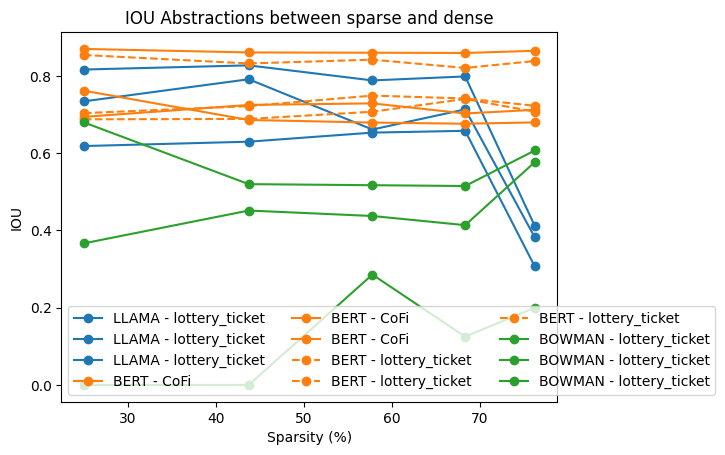

In [260]:
colors = plt.cm.tab10.colors
linestyles = ['-', '--', ':']

model_colors = {model: colors[i] for i, model in enumerate(all_models_all_methods_ious.keys())}

plt.figure()

for model, methods in all_models_all_methods_ious.items():
    for j, (method, vals) in enumerate(methods.items()):
        sparsity = [float(k) for k in vals.keys()]
        scores = list(vals.values())
        sparsity, scores = zip(*sorted(zip(sparsity, scores)))

        plt.plot(
            sparsity,
            scores,
            marker='o',
            color=model_colors[model],
            linestyle=linestyles[j],
            label=f"{model} - {method}"
        )
plt.title('IOU Abstractions between sparse and dense')
plt.xlabel("Sparsity (%)")
plt.ylabel("IOU")
plt.legend(ncol=3)
plt.show()
